* **nombre**: Marcos Bianchi
* **padrón**: 108921

## 1. Implemente un perceptrón simple que aprenda la función lógica AND y la función lógica OR, de 2 y de 4 entradas. Muestre la evolución del error durante el entrenamiento. Para el caso de 2 dimensiones, grafique la recta discriminadora y todos los vectores de entrada de la red.

In [1]:
import matplotlib.pyplot as plt
import numpy as np


def plot_errors(errors: list[float], gate: str):
    xs = list(range(len(errors)))

    plt.figure(figsize=(10, 6))
    plt.plot(xs, errors)
    plt.title(f"Perceptron's classification error per epoch for an {gate} gate")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.xticks(xs)
    plt.grid(True)
    plt.show()


def plot_weights(ws: list[tuple[float, float, float]], gate: str):
    points = [(-1, -1), (-1, 1), (1, -1), (1, 1)]

    x_min, x_max = -1.5, 1.5
    y_min, y_max = -1.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    fig, axes = plt.subplots(1, len(ws), figsize=(6 * len(ws), 6), squeeze=False)

    for ax, (W, B) in zip(axes[0], ws):
        Z = W[0] * xx + W[1] * yy + B
        Z = np.sign(Z)

        ax.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.3, colors=["#ffcccc", "#ccccff"])
        ax.contour(xx, yy, Z, levels=[0], colors="blue")

        xs, ys = zip(*points)
        ax.scatter(xs, ys, color="red", edgecolor="black", zorder=5, label="Points")

        ax.set_title(f"weights: ({W[0].item():.2f}, {W[1].item():.2f}, {B:.2f})")

        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(True)

    fig.suptitle(f"Perceptron's classification per epoch for {gate} gate")
    plt.tight_layout()
    plt.show()


SEED = 1234

$$AND(2)$$
|x1|x2|y|
|-|-|-|
|1|1|1|
|1|-1|-1|
|-1|1|-1|
|-1|-1|-1|

In [2]:
from src.perceptron import Perceptron
from src.utils import truth_table
import numpy as np


m = Perceptron(2, seed=SEED)
X, Y = truth_table(2, lambda xs: 2 * all(x == 1 for x in xs) - 1)

ws, errors = [], []
def tracker(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)
    ws.append((m.W.copy(), m.B))

m.train(X, Y, epoch_f=tracker)

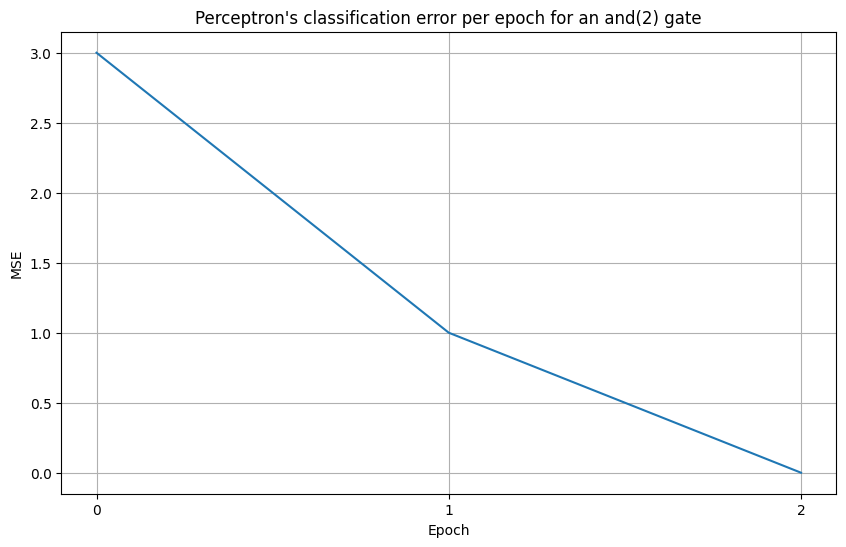

In [3]:
plot_errors(errors, "and(2)")

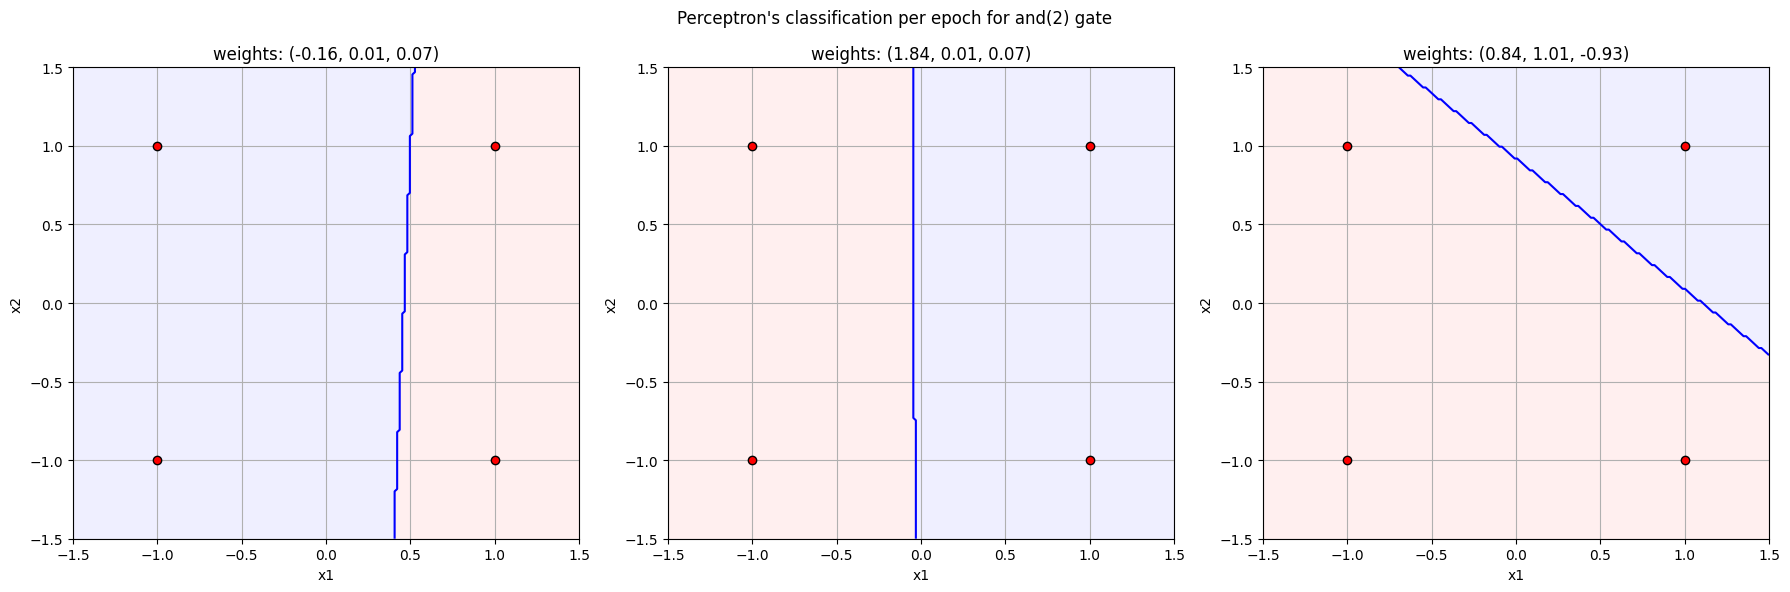

In [4]:
plot_weights(ws, "and(2)")

$$OR(2)$$
|x1|x2|y|
|-|-|-|
|1|1|1|
|1|-1|1|
|-1|1|1|
|-1|-1|-1|

In [5]:
from src.perceptron import Perceptron
from src.utils import truth_table
import numpy as np


m = Perceptron(2, seed=SEED)
X, Y = truth_table(2, lambda xs: 2 * any(x == 1 for x in xs) - 1)

ws, errors = [], []
def tracker(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)
    ws.append((m.W.copy(), m.B))

m.train(X, Y, epoch_f=tracker)

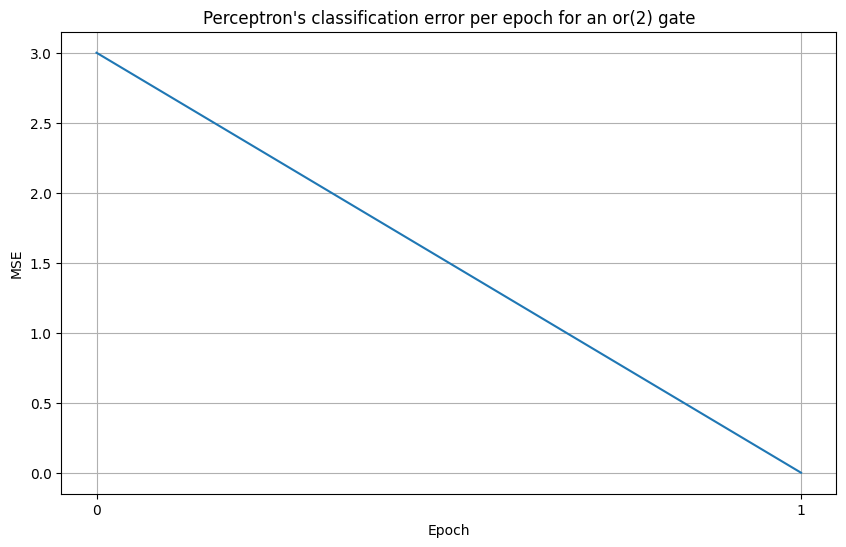

In [6]:
plot_errors(errors, "or(2)")

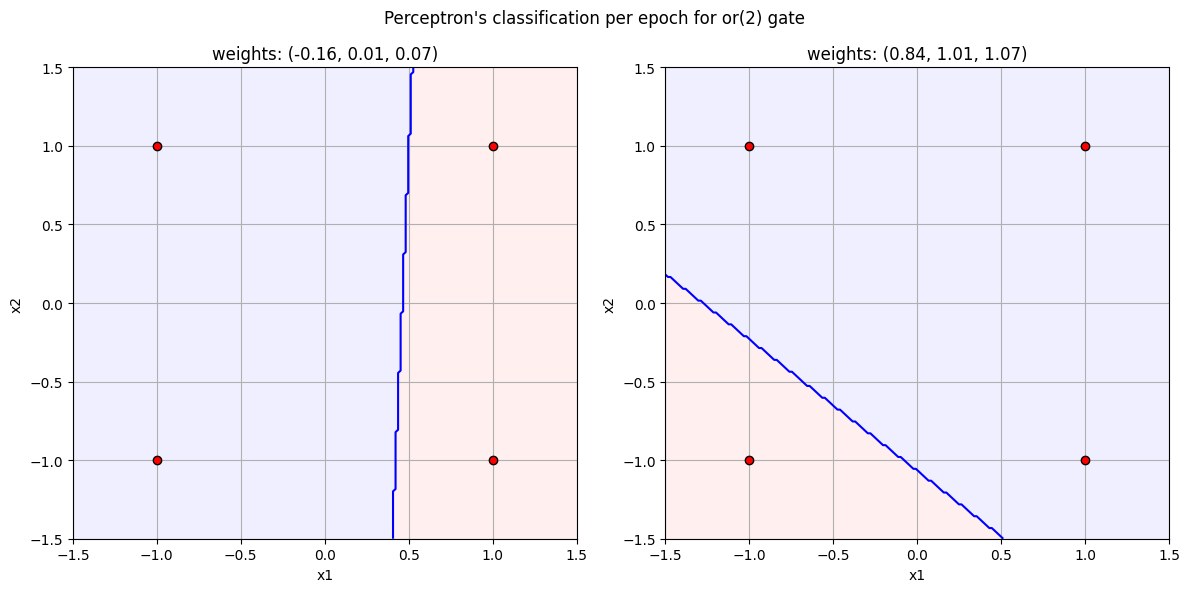

In [7]:
plot_weights(ws, "or(2)")

$$AND(4)$$
|x1|x2|x3|x4|y|
|-|-|-|-|-|
|1|1|1|1|1|
|1|1|1|-1|-1|
|1|1|-1|1|-1|
|1|1|-1|-1|-1|
|1|-1|1|1|-1|
|1|-1|1|-1|-1|
|1|-1|-1|1|-1|
|1|-1|-1|-1|-1|
|-1|1|1|1|-1|
|-1|1|1|-1|-1|
|-1|1|-1|1|-1|
|-1|1|-1|-1|-1|
|-1|-1|1|1|-1|
|-1|-1|1|-1|-1|
|-1|-1|-1|1|-1|
|-1|-1|-1|-1|-1|

In [8]:
from src.perceptron import Perceptron
from src.utils import truth_table
import numpy as np


m = Perceptron(4, seed=SEED)
X, Y = truth_table(4, lambda xs: 2 * all(x == 1 for x in xs) - 1)

errors = []
def tracker(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)

m.train(X, Y, epoch_f=tracker)

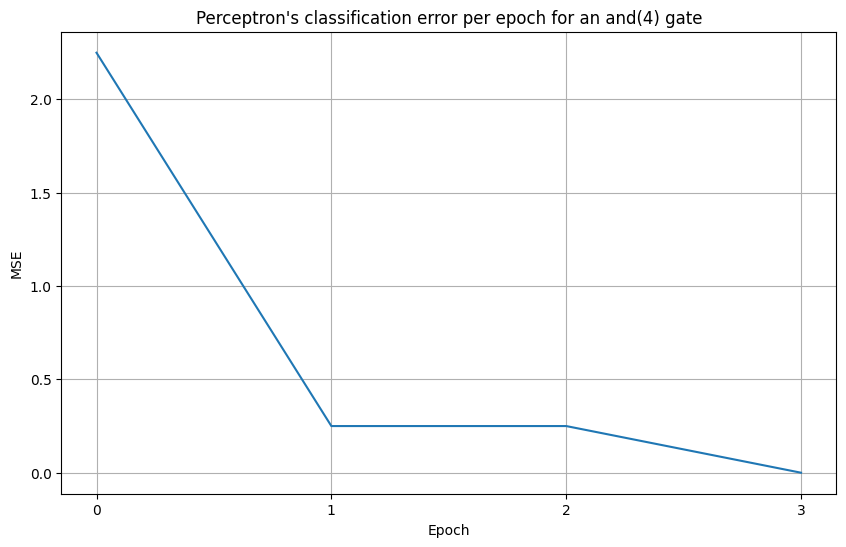

In [9]:
plot_errors(errors, "and(4)")

$$OR(4)$$
|x1|x2|x3|x4|y|
|-|-|-|-|-|
|1|1|1|1|1|
|1|1|1|-1|1|
|1|1|-1|1|1|
|1|1|-1|-1|1|
|1|-1|1|1|1|
|1|-1|1|-1|1|
|1|-1|-1|1|1|
|1|-1|-1|-1|1|
|-1|1|1|1|1|
|-1|1|1|-1|1|
|-1|1|-1|1|1|
|-1|1|-1|-1|1|
|-1|-1|1|1|1|
|-1|-1|1|-1|1|
|-1|-1|-1|1|1|
|-1|-1|-1|-1|-1|

In [10]:
from src.perceptron import Perceptron
from src.utils import truth_table
import numpy as np


m = Perceptron(4, seed=SEED)
X, Y = truth_table(4, lambda xs: 2 * any(x == 1 for x in xs) - 1)

errors = []
def tracker(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)

m.train(X, Y, epoch_f=tracker)

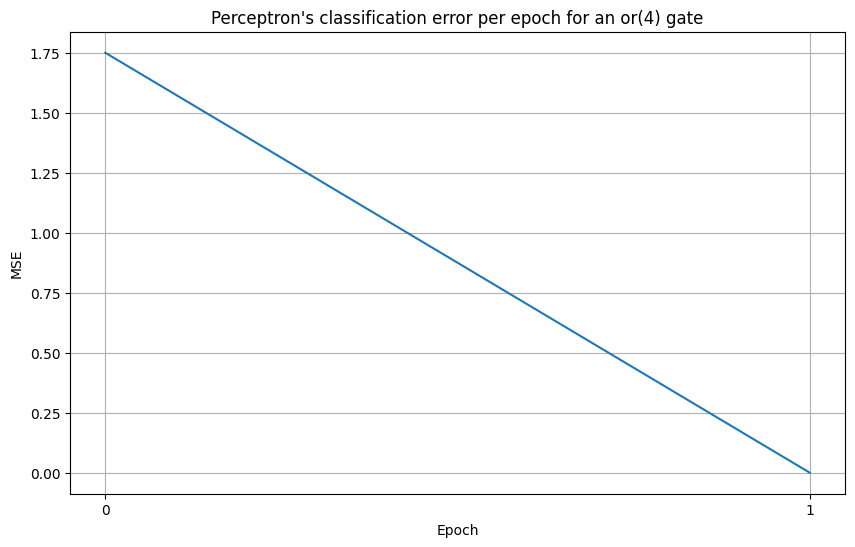

In [11]:
plot_errors(errors, "or(4)")

## 2. Determine numéricamente cómo varía la capacidad del perceptrón simple en función del número de patrones enseñados.

In [12]:
from src.perceptron import Perceptron
import matplotlib.pyplot as plt
import numpy as np


n, n_t = 20, 250
xs = np.arange(1, 4 * n + 1, 2)
ys = [Perceptron.capacity(n, n_p, n_t, seed=SEED, max_iter=100) for n_p in xs]

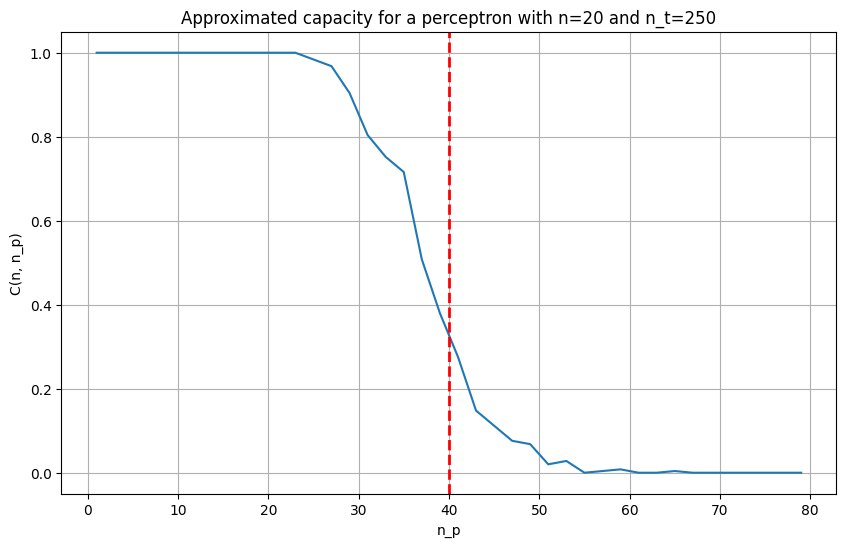

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(xs, ys)
plt.title(f"Approximated capacity for a perceptron with n={n} and n_t={n_t}")
plt.axvline(x=2 * n, color="red", linestyle="--", linewidth=2)
plt.xlabel("n_p")
plt.ylabel("C(n, n_p)")
plt.grid(True)
plt.show()

## 3. Implemente un perceptrón multicapa que aprenda la función lógica XOR de 2 y de 4 entradas (utilizando el algoritmo Backpropagation y actualizando en batch). Muestre cómo evoluciona el error durante el entrenamiento.

In [14]:
from src.layer import Dense, Tanh, Layer
from typing import Optional
from src.utils import windows
import matplotlib.pyplot as plt


def build_xor_arch(neurons: list[int]) -> list[Layer]:
    return sum(([Dense(prev, curr), Tanh()] for prev, curr in windows(neurons, 2)), [])


def plot_errors(errors: list[float], gate: str):
    xs = list(range(len(errors)))

    plt.figure(figsize=(10, 6))
    plt.plot(xs, errors)
    plt.title(f"Multi Layer Perceptron's classification error per epoch an {gate} gate")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.show()


SEED = 1234

$$XOR(2)$$
|x1|x2|y|
|-|-|-|
|1|1|-1|
|1|-1|1|
|-1|1|1|
|-1|-1|-1|

In [15]:
from src.utils import truth_table
from src.errors import mse
from src.mlp import MLP


arch = build_xor_arch([2, 2, 1])
m = MLP(arch, mse, seed=SEED)
X, Y = truth_table(2, lambda xs: 2 * (xs.count(1) % 2 == 1) - 1)

errors = []
def tracker(m: MLP):
    errors.append(m.error(X, Y))

m.train(X, Y, lr=1, epoch_f=tracker)

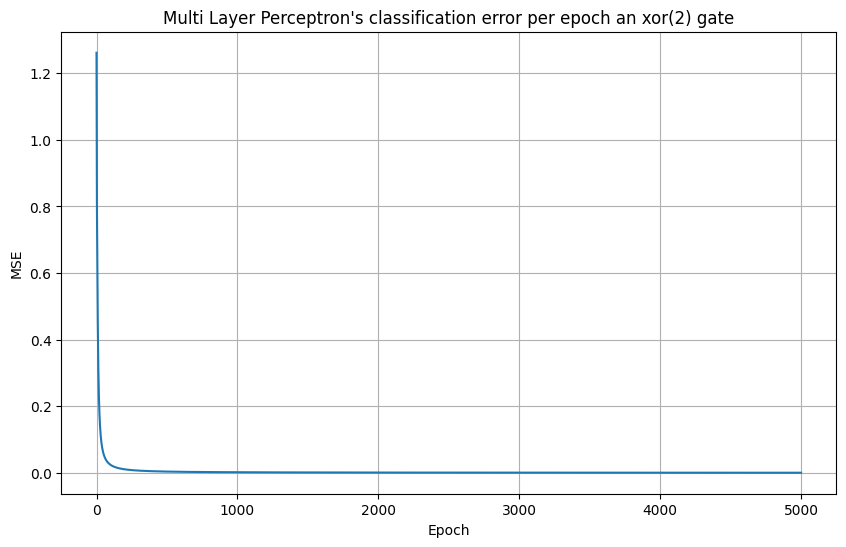

In [16]:
plot_errors(errors, "xor(2)")

$$XOR(4)$$
|x1|x2|x3|x4|y|
|-|-|-|-|-|
|1|1|1|1|-1|
|1|1|1|-1|1|
|1|1|-1|1|1|
|1|1|-1|-1|-1|
|1|-1|1|1|1|
|1|-1|1|-1|-1|
|1|-1|-1|1|-1|
|1|-1|-1|-1|1|
|-1|1|1|1|1|
|-1|1|1|-1|-1|
|-1|1|-1|1|-1|
|-1|1|-1|-1|1|
|-1|-1|1|1|-1|
|-1|-1|1|-1|1|
|-1|-1|-1|1|1|
|-1|-1|-1|-1|-1|

In [17]:
from src.utils import truth_table
from src.errors import mse
from src.mlp import MLP


arch = build_xor_arch([4, 4, 1])
m = MLP(arch, mse, seed=SEED)
X, Y = truth_table(4, lambda xs: 2 * (xs.count(1) % 2 == 1) - 1)

errors = []
def tracker(m: MLP):
    errors.append(m.error(X, Y))

m.train(X, Y, lr=1, epoch_f=tracker)

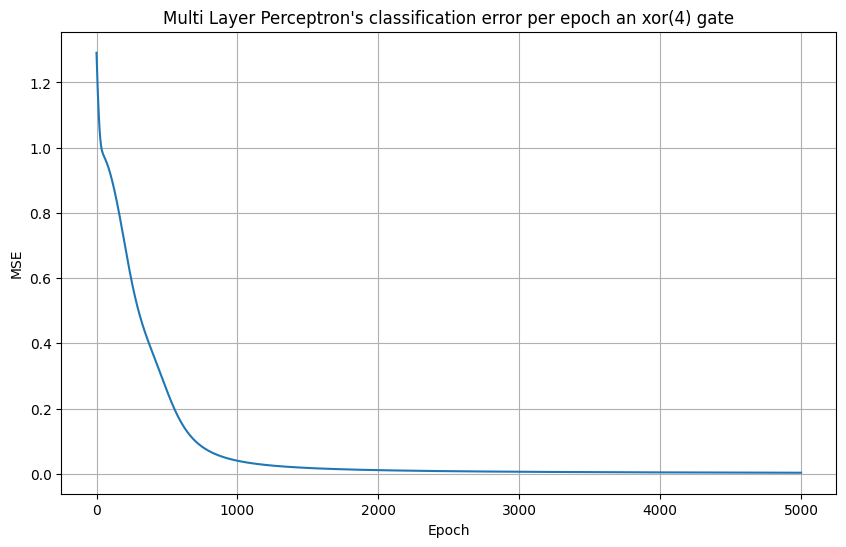

In [18]:
plot_errors(errors, "xor(4)")

## 4-a) Implemente una red con aprendizaje Backpropagation que aprenda la siguiente función: $$f(x, y, z) = sin(x) + cos(y) + z$$
## donde: x e y $\in$ [0, 2$\pi$] y z $\in$ [−1,1]. Para ello construya un conjunto de datos de entrenamiento y un conjunto de evaluación. Muestre la evolución del error de entrenamiento y de evaluación en función de las épocas de entrenamiento.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from src.mlp import MLP


def generate_dataset(n: int, training_ratio: float) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    f = lambda x: np.sin(x[0]) + np.cos(x[1]) + x[2]
    rng = np.random.default_rng(seed=SEED)
    
    x = rng.uniform(0, 2 * np.pi, n)
    y = rng.uniform(0, 2 * np.pi, n)
    z = rng.uniform(-1, 1, n)

    t = int(training_ratio * n)
    
    X = np.column_stack((x, y, z))
    X_train, X_test = X[:t], X[t:]
    
    Y = np.array([f(x) for x in X]).reshape(-1, 1)
    Y_train, Y_test = Y[:t], Y[t:]

    return X_train, X_test, Y_train, Y_test


def plot_errors(train_errors: list[float], test_errors: list[float], func: str):
    xs = list(range(len(train_errors)))

    plt.figure(figsize=(10, 6))
    plt.plot(xs, train_errors, label="train")
    plt.plot(xs, test_errors, label="test")
    plt.title(f"Multi Layer Perceptron's classification error per epoch for {func}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_preds(m: MLP, X: np.ndarray, Y: np.ndarray):
    Y_pred = m.forward(X)
    xs = np.linspace(-3, 3)

    plt.figure(figsize=(10, 6))
    plt.scatter(Y_pred, Y)
    plt.plot(xs, xs, color="red")
    plt.title("Multi Layer Perceptron's predictions vs real values")
    plt.xlabel("Predictions")
    plt.ylabel("Real Values")
    plt.grid(True)
    plt.show()


SEED = 1234

In [20]:
from src.layer import Dense, Tanh
from src.errors import mse
from src.mlp import MLP


arch = [
    Dense(3, 10),
    Tanh(),
    Dense(10, 10),
    Tanh(),
    Dense(10, 1),
    Tanh(a=3.0)
]
m = MLP(arch, mse, seed=SEED)

X_train, X_test, Y_train, Y_test = generate_dataset(100, 0.8)

train_errors, test_errors = [], []
def tracker(m: MLP):
    train_errors.append(m.error(X_train, Y_train))
    test_errors.append(m.error(X_test, Y_test))

m.train(X_train, Y_train, lr=0.2, max_iter=10_000, epoch_f=tracker)

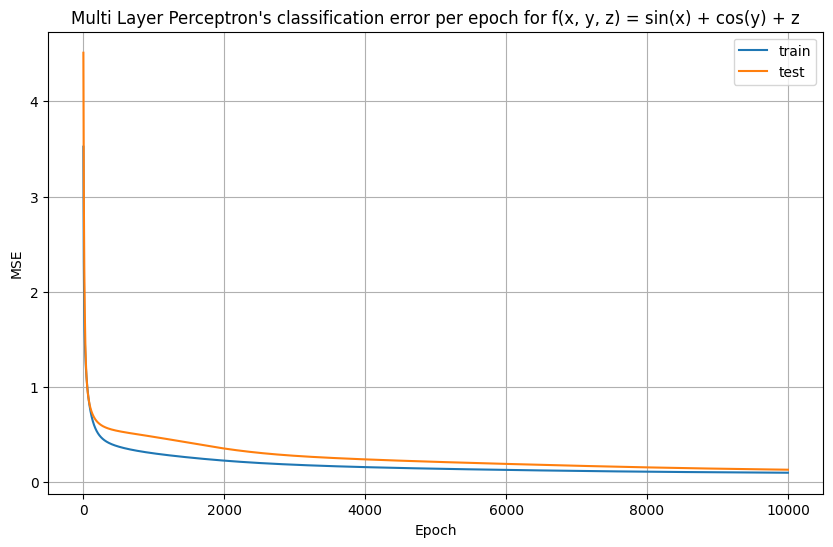

In [21]:
plot_errors(train_errors, test_errors, "f(x, y, z) = sin(x) + cos(y) + z")

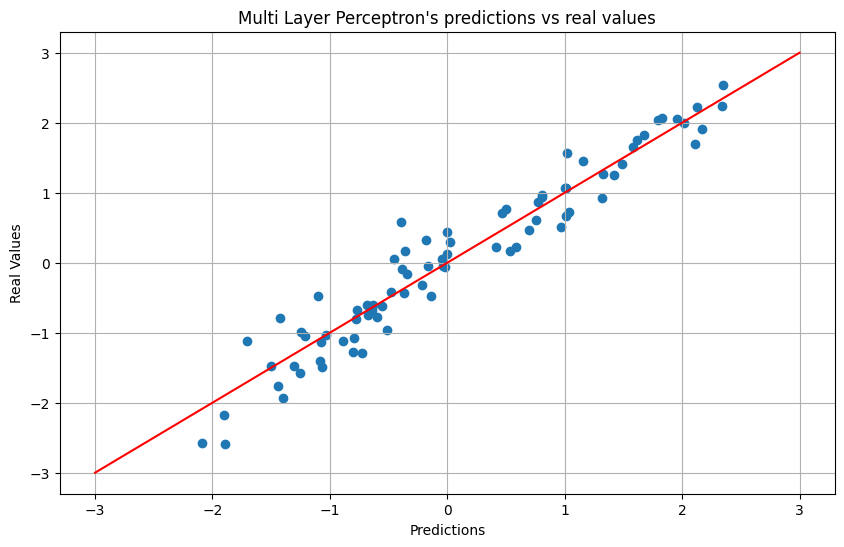

In [22]:
plot_preds(m, X_train, Y_train)

## 4-b) Estudie la evolución de los errores durante el entrenamiento de una red con una capa oculta de 30 neuronas cuando el conjunto de entrenamiento contiene 40 muestras. ¿Que ocurre si el minibatch tiene tamaño 40? ¿Y si tiene tamaño 1?

In [23]:
from src.layer import Dense, Tanh


arch = [
    Dense(3, 30),
    Tanh(),
    Dense(30, 1),
]

X_train, X_test, Y_train, Y_test = generate_dataset(40, 0.8)

In [24]:
from src.errors import mse
from src.mlp import MLP


m = MLP(arch, mse, seed=SEED)

train_errors, test_errors = [], []
def tracker(m: MLP):
    train_errors.append(m.error(X_train, Y_train))
    test_errors.append(m.error(X_test, Y_test))

m.train(X_train, Y_train, lr=0.7, epoch_f=tracker)

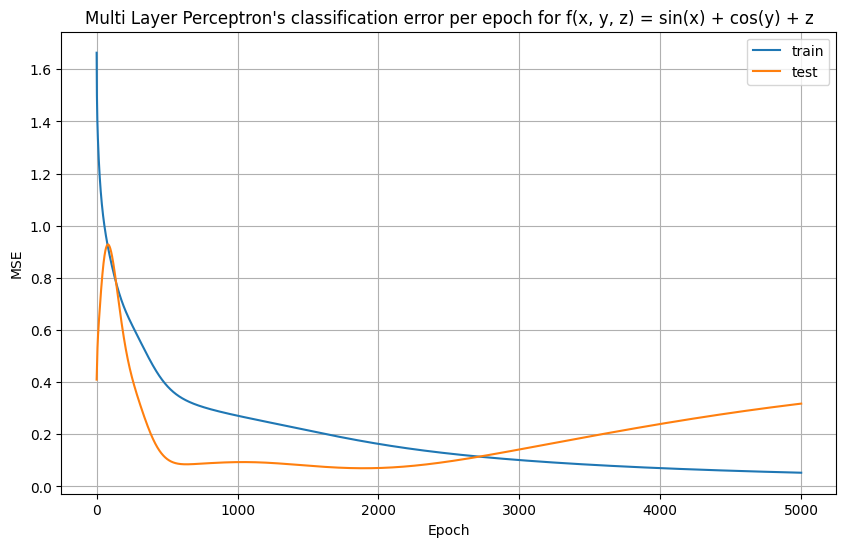

In [25]:
plot_errors(train_errors, test_errors, "f(x, y, z) = sin(x) + cos(y) + z")

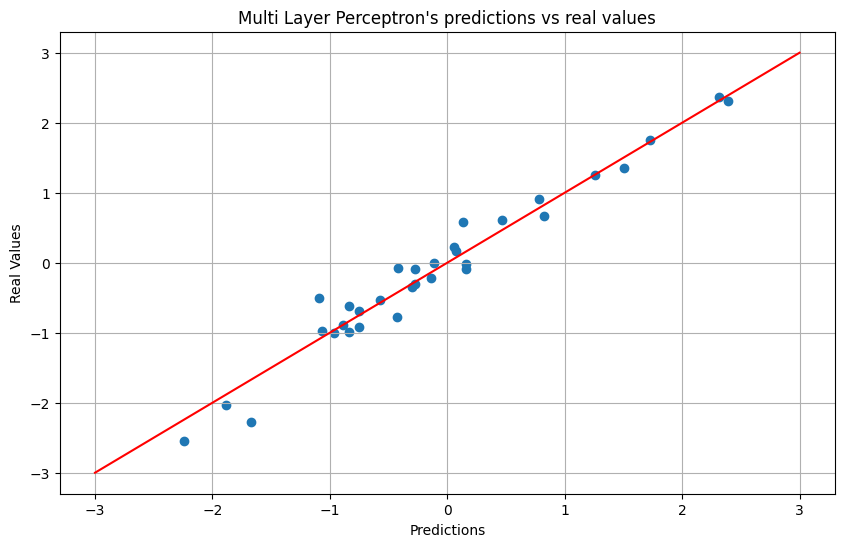

In [26]:
plot_preds(m, X_train, Y_train)

In [27]:
from src.errors import mse
from src.mlp import MLP


m = MLP(arch, mse, seed=SEED)

train_errors, test_errors = [], []
def tracker(m: MLP):
    train_errors.append(m.error(X_train, Y_train))
    test_errors.append(m.error(X_test, Y_test))

m.train(X_train, Y_train, batch_size=1, lr=0.02, epoch_f=tracker)

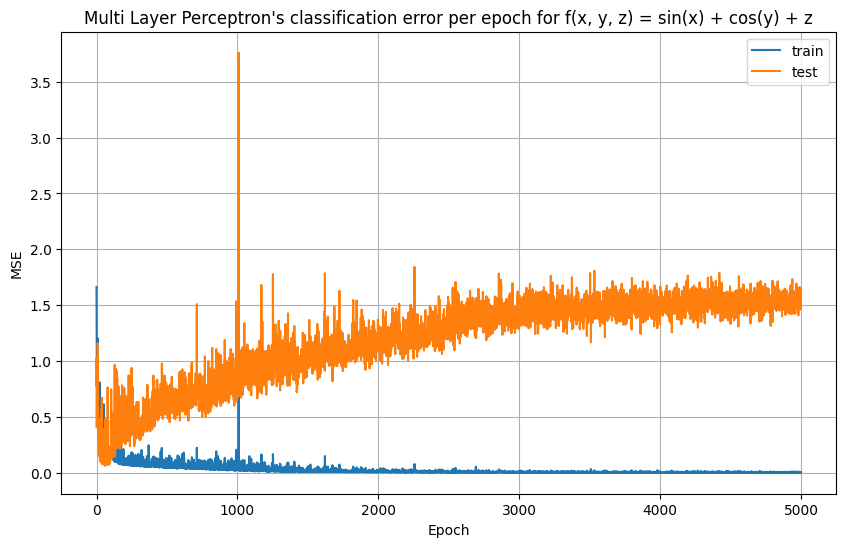

In [28]:
plot_errors(train_errors, test_errors, "f(x, y, z) = sin(x) + cos(y) + z")

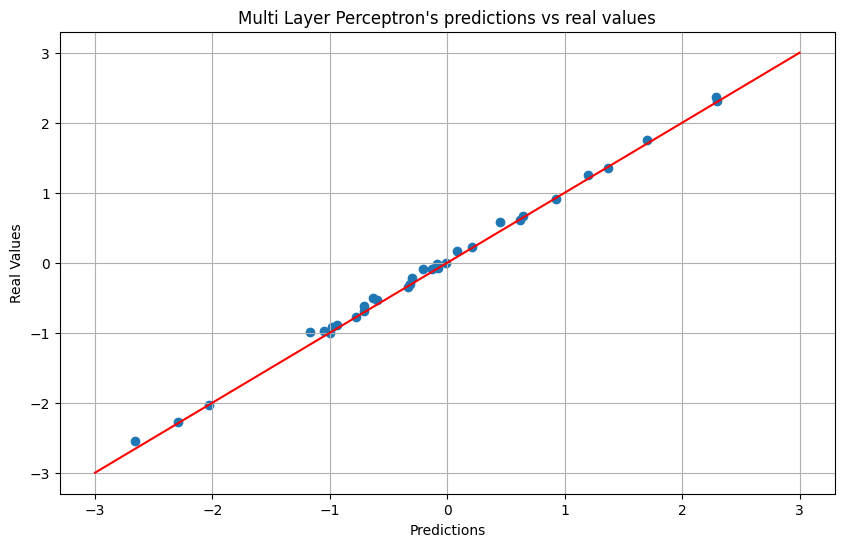

In [29]:
plot_preds(m, X_train, Y_train)

## 5. Siguiendo el trabajo de Hinton y Salakhutdinov (2006), entrene una máquina restringida de Boltzmann con imágenes de la base de datos MNIST. Muestre el error de recontruccion durante el entrenamiento, y ejemplos de cada uno de los dígitos reconstruidos.

In [1]:
import matplotlib.pyplot as plt
from scipy.io import loadmat
from typing import Iterable
import numpy as np


def get_images(path: str) -> np.ndarray:
    return loadmat(path)["data"]


def plot_images(ims: Iterable[np.ndarray], rows: int, cols: int):
    imgs = [np.reshape(im, (28, 28)) for im in ims]

    fig, axs = plt.subplots(rows, cols, figsize=(cols << 1, rows << 1))
    axs = np.array(axs).flatten()

    for ax, img in zip(axs, imgs):
        ax.imshow(img, cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def plot_errors(errors: list[float]):
    xs = list(range(len(errors)))

    plt.figure(figsize=(10, 6))
    plt.plot(xs, errors)
    plt.title(f"Restricted Boltzman Machine's error per epoch")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.show()


SEED = 1234

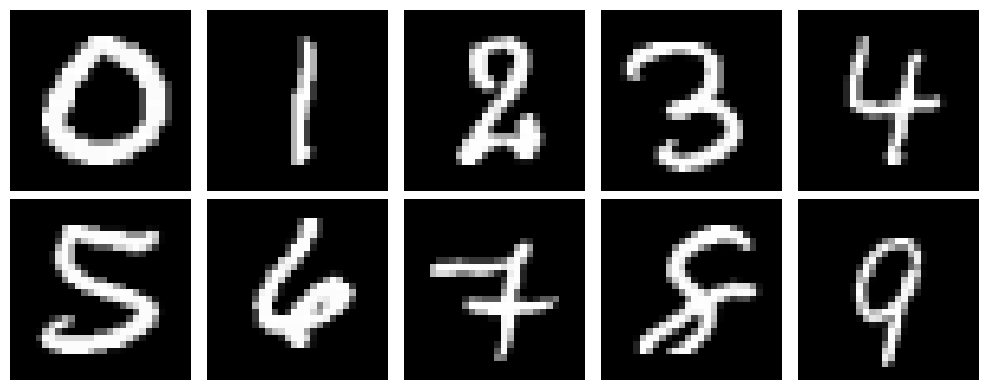

In [2]:
M_train = get_images("images/rbm/train.mat") / 255.0
M_test = get_images("images/rbm/test.mat") / 255.0

digits = [M_test[i] for i in range(0, 200, 20)]
plot_images(digits, 2, 5)

In [3]:
from src.rbm import RBM

v = 784 # size of images
h = 300 # hidden layer size

m = RBM(v, h, seed=SEED)

errors = []
def tracker(m: RBM):
    errors.append(m.mse(M_train))

m.train(M_train, batch_size=20, epoch_f=tracker, max_iter=500, lr=0.1)

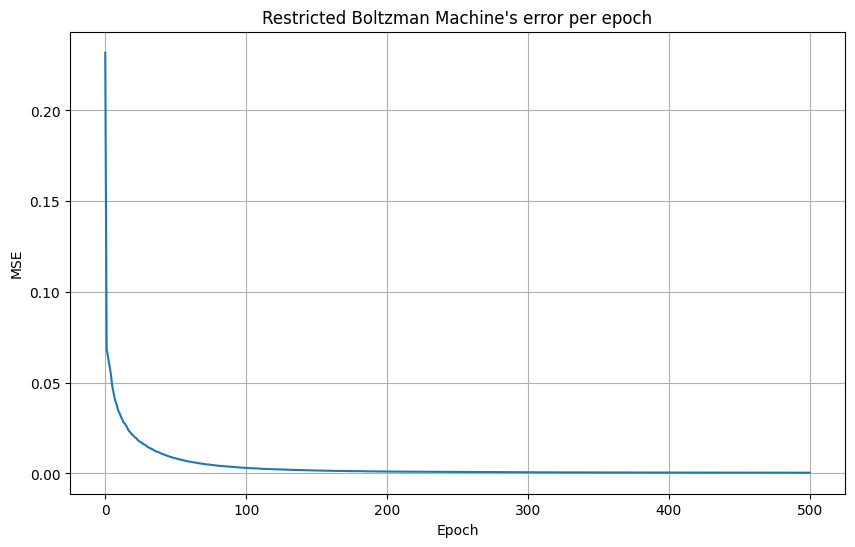

In [5]:
plot_errors(errors)

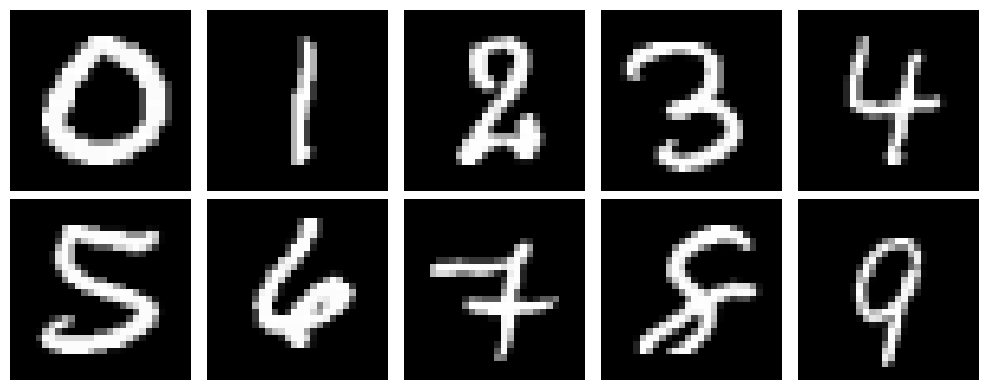

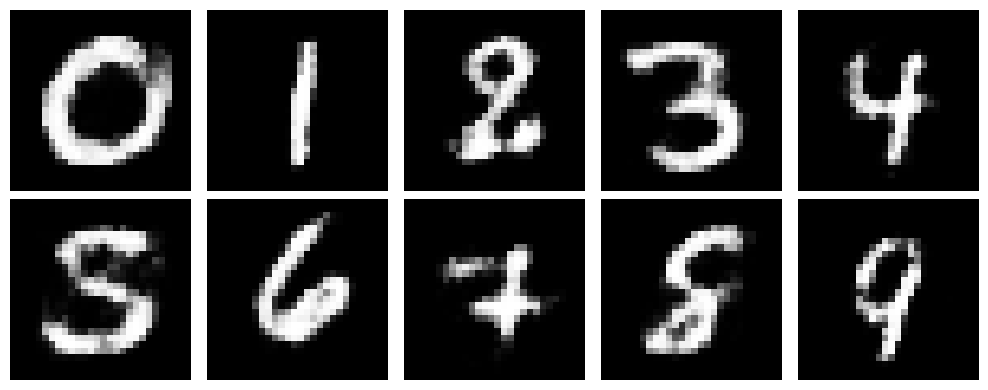

In [6]:
plot_images(digits, 2, 5)
plot_images((m.forward(digit) for digit in digits), 2, 5)

## 6. Entrene una red convolucional para clasificar las imágenes de la base de datos MNIST. ¿Cuál es la red convolucional más pequeña que puede conseguir con una exactitud de al menos 90% en el conjunto de evaluación? ¿Cuál es el perceptrón multicapa más pequeño que puede conseguir con la misma exactitud?

Arranqué usando una red de una capa convolucional, una capa de max pooling y una lineal usando pocos parámetros y obtuve un ~50% de accuracy. Luego cambié el max pooling por avg pooling y subí el learning rate, con esto alcancé un poco más pero no lo suficiente. Agregué otra capa convolucional y la accuracy mejoró rápidamente, siempre intente dejando la capa lineal lo más chica posible para disminuir los pesos de la red. Ajustando un poco los kernels y los canales logré alcanzar accuracy > 90% con ~900 parámetros, también achiqué el batch size y aumenté la cantidad de épocas de entrenamiento de 5 a 10.

In [7]:
import torch
from torch.utils.data import TensorDataset


device = "cpu"
X_train = torch.load("images/conv/train_data.pt").to(torch.float32).to(device)
X_train = X_train.unsqueeze(1)

X_test = torch.load("images/conv/test_data.pt").to(torch.float32).to(device)
X_test = X_test.unsqueeze(1)

Y_train = torch.load("images/conv/train_labels.pt").to(torch.long).to(device)
Y_test = torch.load("images/conv/test_labels.pt").to(torch.long).to(device)

train_set = TensorDataset(X_train, Y_train)
test_set = TensorDataset(X_test, Y_test)

SEED = 1234
torch.manual_seed(SEED);

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Conv(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 5, 2)
        self.pool = nn.AvgPool2d(4, 4)
        self.conv2 = nn.Conv2d(8, 16, 2, 2)
        self.fc = nn.Linear(16, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc(x))
        return x


f_loss = nn.CrossEntropyLoss()
m = Conv().to(device)
optimizer = torch.optim.SGD(m.parameters(), lr=0.01)
parameter_count = sum(p.numel() for p in m.parameters())

print(f"The parameter count is {parameter_count}")

The parameter count is 906


In [9]:
import torch
from torch.utils.data import DataLoader

NEPOCHS = 10
BATCH_SIZE = 32

for epoch in range(1, NEPOCHS + 1):
    loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    print(f"epoch: {epoch}")

    for batch, label in loader:
        outputs = m(batch)
        loss = f_loss(outputs, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

with torch.inference_mode():
    outputs = m(X_test)
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == Y_test).sum().item()
    total = Y_test.size(0)
    print(f"The accuracy of the model is {correct / total}")

epoch: 1
epoch: 2
epoch: 3
epoch: 4
epoch: 5
epoch: 6
epoch: 7
epoch: 8
epoch: 9
epoch: 10
The accuracy of the model is 0.9318


In [10]:
from src.mlp import MLP
import numpy as np


X_train = X_train.reshape(60_000, 28 * 28).numpy()
X_test = X_test.reshape(10_000, 28 * 28).numpy()

Y_train_ohe = np.zeros((60_000, 10))
Y_train_ohe[np.arange(60_000), Y_train] = 1

Y_test_ohe = np.zeros((10_000, 10))
Y_test_ohe[np.arange(10_000), Y_test] = 1


def accuracy(m: MLP, X: np.ndarray, Y: np.ndarray) -> float:
    Z = m.forward(X)
    pred_classes = np.argmax(Z, axis=1)
    real_classes = np.argmax(Y, axis=1)
    return np.mean(pred_classes == real_classes)


SEED = 1234

Con esta red arranque con 1 capa, claramente no fue suficiente e incrementé a 2 lo cual tampoco alcanzó, así que quedé en 3 capas donde se van achicando las dimensiones hasta alcanzar las 10 clases de digitos.

In [11]:
from src.layer import Dense, Tanh, SoftMax
from src.errors import cross_entropy
from src.mlp import MLP

# Total parameters: 317.402
arch = [
    Dense(28 * 28, 392), # 28^2 * 392 + 392 = 307.720
    Tanh(),
    Dense(392, 24),      # 392 * 24 + 24 = 9.432
    Tanh(),
    Dense(24, 10),       # 24 * 10 + 10 = 250
    SoftMax(),
]
m = MLP(arch, cross_entropy, seed=SEED)

In [12]:
%%time

m.train(X_train, Y_train_ohe, batch_size=32, lr=0.01, max_iter=10)

CPU times: user 13min 25s, sys: 9.01 s, total: 13min 34s
Wall time: 1min 46s


In [13]:
print(f"The accuracy of the model is {accuracy(m, X_test, Y_test_ohe)}")

The accuracy of the model is 0.9134


Con el perceptrón multicapa conseguimos un poco menos de accuracy pero con un coste muchisimo mayor, tiene ~350x los parámetros que tiene la red convolucional.

## 7. Entrene un autoencoder para obtener una representación de baja dimensionalidad de las imágenes de MNIST. Use dichas representaciones para entrenar un perceptrón multicapa como clasificador. ¿Cuál es el tiempo de entrenamiento y la exactitud del clasificador obtenido cuando parte de la representación del autoencoder, en comparación con lo obtenido usando las imágenes originales?

In [1]:
import torch
from torch.utils.data import TensorDataset
import numpy as np


device = "cpu"

X_train = torch.load("images/conv/train_data.pt").to(torch.float32).to(device) / 255.0
X_train = X_train.unsqueeze(1)
X_train = X_train.reshape(60_000, 28 * 28)

X_test = torch.load("images/conv/test_data.pt").to(torch.float32).to(device) / 255.0
X_test = X_test.unsqueeze(1)
X_test = X_test.reshape(10_000, 28 * 28)

train_set = TensorDataset(X_train, X_train)
test_set = TensorDataset(X_test, X_test)

SEED = 1234
torch.manual_seed(SEED);

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


m = AE().to(device)
f_loss = nn.MSELoss()
optimizer = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-8)
parameter_count = sum(p.numel() for p in m.parameters())

print(f"The parameter count is {parameter_count}")

The parameter count is 222384


In [3]:
import torch
from torch.utils.data import DataLoader

NEPOCHS = 10
BATCH_SIZE = 32

for epoch in range(1, NEPOCHS + 1):
    loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    print(f"epoch: {epoch}")

    for batch, _ in loader:
        outputs = m(batch)
        loss = f_loss(outputs, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

with torch.inference_mode():
    loss = f_loss(m(X_test), X_test)
    print(loss)

epoch: 1
epoch: 2
epoch: 3
epoch: 4
epoch: 5
epoch: 6
epoch: 7
epoch: 8
epoch: 9
epoch: 10
tensor(0.0118)


In [4]:
import torch


encoder = m.encoder

with torch.inference_mode():
    X_train_R = encoder(X_train)
    X_test_R = encoder(X_test)

Y_train = torch.load("images/conv/train_labels.pt").to(torch.long).to(device)
Y_test = torch.load("images/conv/test_labels.pt").to(torch.long).to(device)

train_set = TensorDataset(X_train_R, Y_train)

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DecoderClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.model(x)


f_loss = nn.CrossEntropyLoss()
m = DecoderClassifier().to(device)
optimizer = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-8)
parameter_count = sum(p.numel() for p in m.parameters())

print(f"The parameter count is {parameter_count}")

The parameter count is 46026


In [10]:
%%time

import torch
from torch.utils.data import DataLoader


NEPOCHS = 20
BATCH_SIZE = 32

for epoch in range(1, NEPOCHS + 1):
    loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    print(f"epoch: {epoch}")

    for batch, label in loader:
        outputs = m(batch)
        loss = f_loss(outputs, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

epoch: 1
epoch: 2
epoch: 3
epoch: 4
epoch: 5
epoch: 6
epoch: 7
epoch: 8
epoch: 9
epoch: 10
epoch: 11
epoch: 12
epoch: 13
epoch: 14
epoch: 15
epoch: 16
epoch: 17
epoch: 18
epoch: 19
epoch: 20
CPU times: user 3min 53s, sys: 620 ms, total: 3min 54s
Wall time: 58.7 s


In [11]:
with torch.inference_mode():
    outputs = m(X_test_R)
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == Y_test).sum().item()
    total = Y_test.size(0)
    print(f"The accuracy of the model is {correct / total}")

The accuracy of the model is 0.878


El perceptrón multi capa tomó ~1.5 minutos en entrenar y logró una accuracy >90%. En cambio el modelo con datos encodeados se tomó ~1 minuto y logró una accuracy de >87%.